<a href="https://colab.research.google.com/github/banuben/computer_vision/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('Menu Detector!')

Menu Detector!


In [1]:
# -----------------
# Import Libraries
# -----------------


import torch
import torch.nn as nn
# import torch.optim as optim

from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from torchvision import transforms    # this's working
import torchvision.transforms as transforms
# from torchvision.datasets import ImageFolder
# from torch.utils.data import DataLoader
from google.colab import drive
drive.mount('/content/drive')

from torch.utils.data import Dataset, DataLoader
from PIL import Image, UnidentifiedImageError
import os
import numpy as np




Mounted at /content/drive


In [15]:
# Define Dataset Path

DATASET_PATH = '/content/drive/MyDrive/food101_dataset'
# print('Dataset_path:',DATASET_PATH)


CUSTOM_CLASS_MAPPING = {
    'hamburger': 'hamburger',
    'hot_dog': 'hot_dog',
    'chocolate_cake': 'dessert',  # Label Grouping | class consolidation
    'cheesecake': 'dessert',
    'kebab': 'kebab',
    'pilaf': 'pilaf'
}


CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
#print('Classes:',CLASSES)
#print('Class_to_box:',CLASS_TO_IDX)
#print('Num_classes:',NUM_CLASSES)


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [16]:
# --------------------
# Custom Dataset Class
# --------------------

class FoodDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        #print('images_length', len(self.images))
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        # print('image_path', img_path)

        label = self.labels[idx]
        # print('label', label)

        try:
            image = Image.open(img_path)
            if image.mode == 'P' or image.mode == 'RGBA':
                image = image.convert('RGBA').convert('RGB')
            else:
                image = image.convert('RGB')
        except (UnidentifiedImageError, OSError):
            print(f"Skipping broken image: {img_path}")
            return self.__getitem__((idx + 1) % len(self))

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
# --------------------
# Gather and Split Data
# --------------------

all_images = []

for original_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
    class_path = os.path.join(DATASET_PATH, original_class)
    # print('class_path', class_path)

    if not os.path.exists(class_path):
        print('Warning: {class_path} not found')
        continue

    for img in os.listdir(class_path):
        if img.endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(class_path, img)
            all_images.append((full_path, CLASS_TO_IDX[mapped_class]))


np.random.shuffle(all_images)

split = int(0.8 * len(all_images))

train_data = all_images[:split]
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

# print('all_images:', all_images)

dataset = FoodDataset(train_images, train_labels)
# print(len(dataset))

img, lbl = dataset[0]

In [31]:
train_dataset = FoodDataset(train_images, train_labels, transform=transform)
val_dataset = FoodDataset(val_images, val_labels, transform=transform)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)  # thread | parallel loading for speed
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)  # thread | parallel loading for speed
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)



In [32]:
# pretrained model

model = mobilenet_v2(
    weights=MobileNet_V2_Weights.IMAGENET1K_V1
)  # pretrained model | lightweight | CNN

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)  # fine-tuning | backbone | model layer freeze

#

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
model = model.to(device)

Device: cuda


In [34]:
criterion = nn.CrossEntropyLoss()  # Loss Function | shows in percentage
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # weight
torch.backends.cudnn.benchmark = True  # Benchmark Setting | Trick | 10-20% faster

# print('Criterion:', criterion)
# print('Optimizer:', optimizer)

In [35]:
# -------------
# Training Loop
# -------------

NUM_EPOCHS = 10
best_accuracy = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()   # train mode
    running_loss = 0.0    # 70% | 30% Loss | 100%

    for images, labels in train_loader:  # Forward and Backward(Backpropagation)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # zero the gradient

        outputs = model(images)  # Forward Pass | Dog | 5 classes
        loss = criterion(outputs, labels)  # Calculate Loss

        loss.backward()
        optimizer.step()  # Adam optimizer

        running_loss += loss.item()   # Track Loss

    # Validation
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total   # Calculate Validation Accuracy

    print(
        f'Epoch [{epoch + 1}/{NUM_EPOCHS}], '
        f'Loss: {running_loss / len(train_loader):.4f}, '
        f'Validation Accuracy: {val_acc:.2f}%'
    )

    if val_acc > best_accuracy:
        best_accuracy = val_acc

        torch.save(model.state_dict(), '/content/menu_detector.pth')
        print('Saved New Best Model')

print('Training Complete')

Epoch [1/10], Loss: 0.4842, Validation Accuracy: 85.29%
Saved New Best Model
Epoch [2/10], Loss: 0.2998, Validation Accuracy: 82.82%
Epoch [3/10], Loss: 0.3218, Validation Accuracy: 87.14%
Saved New Best Model
Epoch [4/10], Loss: 0.2006, Validation Accuracy: 89.86%
Saved New Best Model
Epoch [5/10], Loss: 0.1770, Validation Accuracy: 88.50%
Epoch [6/10], Loss: 0.1635, Validation Accuracy: 88.63%
Epoch [7/10], Loss: 0.1800, Validation Accuracy: 90.23%
Saved New Best Model
Epoch [8/10], Loss: 0.1793, Validation Accuracy: 86.77%
Epoch [9/10], Loss: 0.1532, Validation Accuracy: 89.49%
Epoch [10/10], Loss: 0.1625, Validation Accuracy: 89.00%
Training Complete


# **menu_detector model usage**

Upload one or more images of hamburger or hot dog:


Saving 124545.jpg to 124545.jpg


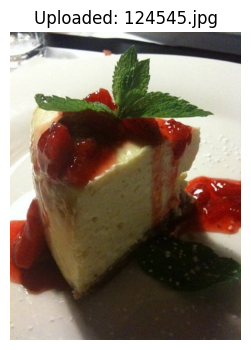

Prediction:
✅ dessert: 100.00%
✅ hot_dog: 0.00%
✅ hamburger: 0.00%
✅ kebab: 0.00%


In [36]:
# -----------------
# Required Libraries
# -----------------


import torch
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision import transforms
from google.colab import files
from PIL import Image, UnidentifiedImageError
import io
import matplotlib.pyplot as plt


# ----------------------------------
# Define Semantic Classes
# ----------------------------------

CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

# ---------------------------------------------------
# Transform for Uploaded Images (no augmentation!)
# ---------------------------------------------------


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ----------------------------------
# Load Model
# ----------------------------------
model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()



# ----------------------------------
# Upload & Predict
# ----------------------------------


print("Upload one or more images of your food:")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

    # Predict
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        topk = torch.topk(probs, 4)

    print("Prediction:")

    for i in range(topk.indices.size(0)):
        label = CLASSES[topk.indices[i]]
        confidence = topk.values[i].item() * 100

        print(f"✅ {label}: {confidence:.2f}%")
